In [18]:
!pip install yellowbrick

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [19]:
df = pd.read_csv("/content/USArrests.csv", index_col=0)
df.head()
df.isnull().sum()
df.info()
df.describe().T

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


,0
Murder,0
Assault,0
UrbanPop,0
Rape,0


<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB


,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.788,4.355510,0.8,4.075,7.25,11.250,17.4
Assault,50.0,170.760,83.337661,45.0,109.000,159.00,249.000,337.0
UrbanPop,50.0,65.540,14.474763,32.0,54.500,66.00,77.750,91.0
Rape,50.0,21.232,9.366385,7.3,15.075,20.10,26.175,46.0


In [20]:
sc = MinMaxScaler((0, 1))
df = sc.fit_transform(df)
df[0:5]

array([[0.74698795, 0.65410959, 0.44067797, 0.35917313],
       [0.55421687, 0.74657534, 0.27118644, 0.96124031],
       [0.43975904, 0.85273973, 0.81355932, 0.6124031 ],
       [0.48192771, 0.49657534, 0.30508475, 0.31524548],
       [0.4939759 , 0.79109589, 1.        , 0.86046512]])

In [21]:
kmeans = KMeans(n_clusters=4, random_state=17).fit(df)
kmeans.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 4,
 'n_init': 'auto',
 'random_state': 17,
 'tol': 0.0001,
 'verbose': 0}

In [22]:
kmeans.n_clusters
kmeans.cluster_centers_
kmeans.labels_
kmeans.inertia_

4

array([[0.1686747 , 0.11485774, 0.34028683, 0.12601868],
       [0.6124498 , 0.75      , 0.75423729, 0.67980189],
       [0.30439405, 0.32937147, 0.70588235, 0.31098951],
       [0.79141566, 0.6802226 , 0.36864407, 0.36466408]])

array([3, 1, 1, 3, 1, 1, 2, 2, 1, 3, 2, 0, 1, 2, 0, 2, 0, 3, 0, 1, 2, 1,
       0, 3, 2, 0, 0, 1, 0, 2, 1, 1, 3, 0, 2, 2, 2, 2, 2, 3, 0, 3, 1, 2,
       0, 2, 2, 0, 0, 2], dtype=int32)

3.683456153585914

Text(0.5, 0, 'Farklı K Değerlerine Karşılık SSE/SSR/SSD')

Text(0.5, 1.0, 'Optimum Küme sayısı için Elbow Yöntemi')

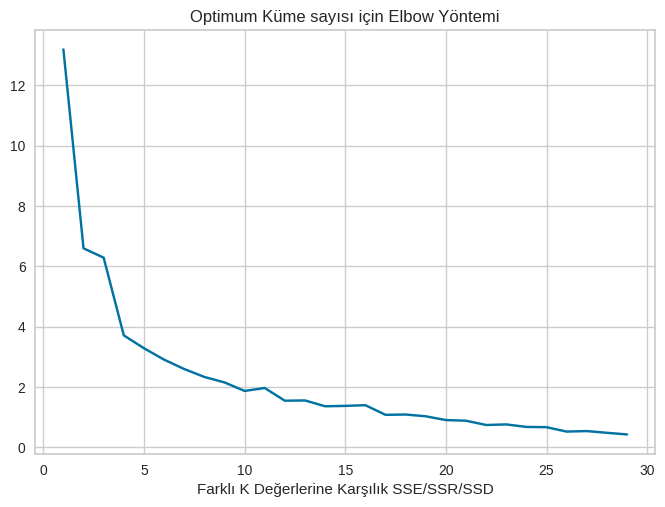

KElbowVisualizer(ax=<Axes: >, estimator=KMeans(n_clusters=19), k=(2, 20))

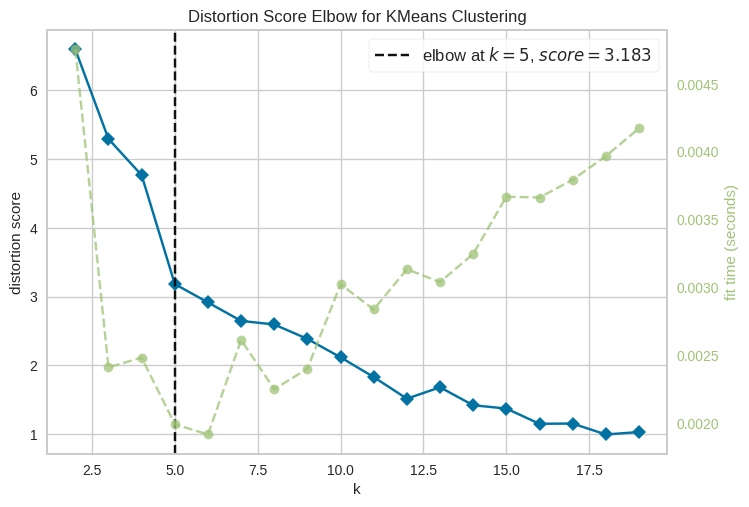

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

np.int64(5)

In [23]:
kmeans = KMeans()
ssd = []
K = range(1, 30)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(df)
    ssd.append(kmeans.inertia_)

plt.plot(K, ssd, "bx-")
plt.xlabel("Farklı K Değerlerine Karşılık SSE/SSR/SSD")
plt.title("Optimum Küme sayısı için Elbow Yöntemi")
plt.show()

kmeans = KMeans()
elbow = KElbowVisualizer(kmeans, k=(2, 20))
elbow.fit(df)
elbow.show()

elbow.elbow_value_

In [24]:
kmeans = KMeans(n_clusters=elbow.elbow_value_).fit(df)

kmeans.n_clusters
kmeans.cluster_centers_
kmeans.labels_
df[0:5]

clusters_kmeans = kmeans.labels_

df = pd.read_csv("/content/USArrests.csv", index_col=0)

df["cluster"] = clusters_kmeans

df.head()

df["cluster"] = df["cluster"] + 1

df[df["cluster"]==5]

df.groupby("cluster").agg(["count","mean","median"])

df.to_csv("clusters.csv")

np.int64(5)

array([[0.40963855, 0.5053816 , 0.82808717, 0.31672204],
       [0.30935507, 0.26571313, 0.58624128, 0.30521356],
       [0.83562823, 0.70645793, 0.37772397, 0.37172388],
       [0.60542169, 0.77671233, 0.73728814, 0.7255814 ],
       [0.11311914, 0.08523592, 0.29378531, 0.08182601]])

array([2, 3, 3, 1, 3, 3, 1, 0, 3, 2, 1, 4, 0, 1, 4, 1, 1, 2, 4, 3, 0, 3,
       1, 2, 0, 1, 1, 3, 4, 0, 3, 3, 2, 4, 1, 1, 1, 1, 0, 2, 4, 2, 0, 1,
       4, 1, 1, 4, 4, 1], dtype=int32)

array([[0.74698795, 0.65410959, 0.44067797, 0.35917313],
       [0.55421687, 0.74657534, 0.27118644, 0.96124031],
       [0.43975904, 0.85273973, 0.81355932, 0.6124031 ],
       [0.48192771, 0.49657534, 0.30508475, 0.31524548],
       [0.4939759 , 0.79109589, 1.        , 0.86046512]])

,Murder,Assault,UrbanPop,Rape,cluster
Alabama,13.2,236,58,21.2,2
Alaska,10.0,263,48,44.5,3
Arizona,8.1,294,80,31.0,3
Arkansas,8.8,190,50,19.5,1
California,9.0,276,91,40.6,3


,Murder,Assault,UrbanPop,Rape,cluster
Idaho,2.6,120,54,14.2,5
Iowa,2.2,56,57,11.3,5
Maine,2.1,83,51,7.8,5
New Hampshire,2.1,57,56,9.5,5
North Dakota,0.8,45,44,7.3,5
South Dakota,3.8,86,45,12.8,5
Vermont,2.2,48,32,11.2,5
West Virginia,5.7,81,39,9.3,5
Wisconsin,2.6,53,66,10.8,5


Murder                   Assault                    UrbanPop  \
         count       mean median   count        mean median    count   
cluster                                                                
1            7   7.600000    7.4       7  192.571429  178.0        7   
2           17   5.935294    6.0      17  122.588235  115.0       17   
3            7  14.671429   14.4       7  251.285714  249.0        7   
4           10  10.850000   11.2      10  271.800000  269.5       10   
5            9   2.677778    2.2       9   69.888889   57.0        9   

                           Rape                    
              mean median count       mean median  
cluster                                            
1        80.857143   83.0     7  19.557143   18.8  
2        66.588235   66.0    17  19.111765   19.5  
3        54.285714   58.0     7  21.685714   22.2  
4        75.500000   79.0    10  35.380000   33.6  
5        49.333333   51.0     9  10.466667   10.8

<Figure size 1000x500 with 0 Axes>

Text(0.5, 1.0, 'Hiyerarşik Kümeleme Dendogramı')

Text(0.5, 0, 'Gözlem Birimleri')

Text(0, 0.5, 'Uzaklıklar')

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [35.0, 35.0, 45.0, 45.0],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [40.0, 40.0, 62.5, 62.5],
  [12.5, 12.5, 51.25, 51.25],
  [85.0, 85.0, 95.0, 95.0],
  [105.0, 105.0, 115.0, 115.0],
  [90.0, 90.0, 110.0, 110.0],
  [31.875, 31.875, 100.0, 100.0],
  [125.0, 125.0, 135.0, 135.0],
  [165.0, 165.0, 175.0, 175.0],
  [185.0, 185.0, 195.0, 195.0],
  [170.0, 170.0, 190.0, 190.0],
  [215.0, 215.0, 225.0, 225.0],
  [205.0, 205.0, 220.0, 220.0],
  [255.0, 255.0, 265.0, 265.0],
  [245.0, 245.0, 260.0, 260.0],
  [235.0, 235.0, 252.5, 252.5],
  [212.5, 212.5, 243.75, 243.75],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [228.125, 228.125, 282.5, 282.5],
  [180.0, 180.0, 255.3125, 255.3125],
  [155.0, 155.0, 217.65625, 217.65625],
  [145.0, 145.0, 186.328125, 186.328125],
  [130.0, 130.0, 165.6640625, 165.6640625],
  [65.9375, 65.9375, 147.83203125, 147.83203125],
  [335.0, 335.0, 345.0, 345.0],
  

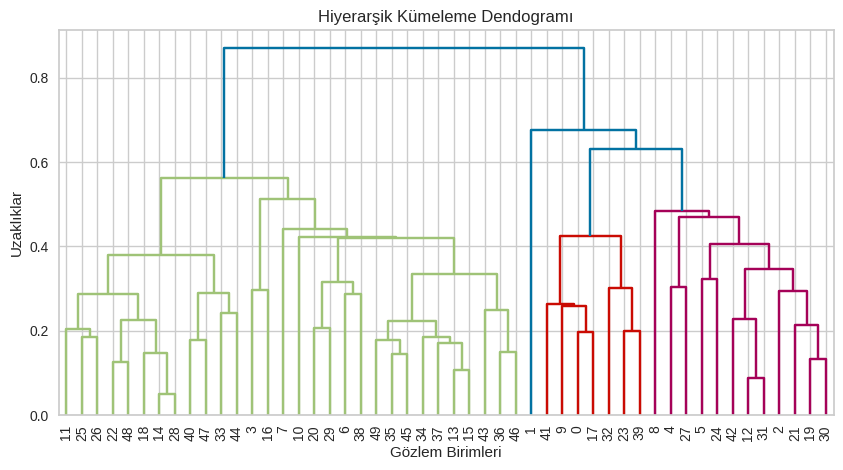

<Figure size 700x500 with 0 Axes>

Text(0.5, 1.0, 'Hiyerarşik Kümeleme Dendogramı')

Text(0.5, 0, 'Gözlem Birimleri')

Text(0, 0.5, 'Uzaklıklar')

{'icoord': [[25.0, 25.0, 35.0, 35.0],
  [15.0, 15.0, 30.0, 30.0],
  [5.0, 5.0, 22.5, 22.5],
  [55.0, 55.0, 65.0, 65.0],
  [85.0, 85.0, 95.0, 95.0],
  [75.0, 75.0, 90.0, 90.0],
  [60.0, 60.0, 82.5, 82.5],
  [45.0, 45.0, 71.25, 71.25],
  [13.75, 13.75, 58.125, 58.125]],
 'dcoord': [[0.0,
   np.float64(0.44128535975867217),
   np.float64(0.44128535975867217),
   0.0],
  [0.0,
   np.float64(0.512131785430662),
   np.float64(0.512131785430662),
   np.float64(0.44128535975867217)],
  [0.0,
   np.float64(0.5626480726951584),
   np.float64(0.5626480726951584),
   np.float64(0.512131785430662)],
  [0.0, np.float64(0.42493155713515973), np.float64(0.42493155713515973), 0.0],
  [0.0, np.float64(0.4682322985813934), np.float64(0.4682322985813934), 0.0],
  [0.0,
   np.float64(0.48321889995489237),
   np.float64(0.48321889995489237),
   np.float64(0.4682322985813934)],
  [np.float64(0.42493155713515973),
   np.float64(0.6306753894842594),
   np.float64(0.6306753894842594),
   np.float64(0.4832188999

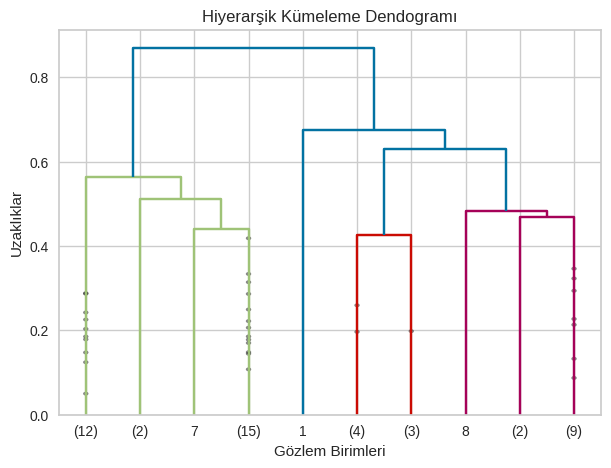

In [25]:
df = pd.read_csv("/content/USArrests.csv", index_col=0)

sc = MinMaxScaler((0, 1))
df = sc.fit_transform(df)

hc_average = linkage(df, "average")

plt.figure(figsize=(10, 5))
plt.title("Hiyerarşik Kümeleme Dendogramı")
plt.xlabel("Gözlem Birimleri")
plt.ylabel("Uzaklıklar")
dendrogram(hc_average,
           leaf_font_size=10)
plt.show()


plt.figure(figsize=(7, 5))
plt.title("Hiyerarşik Kümeleme Dendogramı")
plt.xlabel("Gözlem Birimleri")
plt.ylabel("Uzaklıklar")
dendrogram(hc_average,
           truncate_mode="lastp",
           p=10,
           show_contracted=True,
           leaf_font_size=10)
plt.show()

<Figure size 700x500 with 0 Axes>

Text(0.5, 1.0, 'Dendrograms')

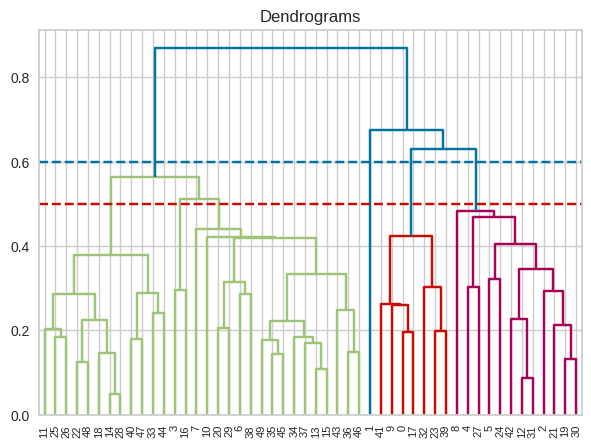

In [26]:
plt.figure(figsize=(7, 5))
plt.title("Dendrograms")
dend = dendrogram(hc_average)
plt.axhline(y=0.5, color='r', linestyle='--')
plt.axhline(y=0.6, color='b', linestyle='--')
plt.show()

In [27]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5, linkage="average")

clusters = cluster.fit_predict(df)

df = pd.read_csv("/content/USArrests.csv", index_col=0)
df["hi_cluster_no"] = clusters

df["hi_cluster_no"] = df["hi_cluster_no"] + 1

df["kmeans_cluster_no"] = df["kmeans_cluster_no"]  + 1
df["kmeans_cluster_no"] = clusters_kmeans

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [33]:
df = pd.read_csv("/content/hitters.csv")
df.head()

num_cols = [col for col in df.columns if df[col].dtypes != "O" and "Salary" not in col]

df[num_cols].head()

df = df[num_cols]
df.dropna(inplace=True)
df.shape

df = StandardScaler().fit_transform(df)

pca = PCA()
pca_fit = pca.fit_transform(df)

pca.explained_variance_ratio_
np.cumsum(pca.explained_variance_ratio_)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
0,293,66,1,30,29,14,1,293,66,1,30,29,14,446,33,20
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4


(322, 16)

array([4.60378552e-01, 2.60398491e-01, 1.03388605e-01, 5.36902121e-02,
       4.20784091e-02, 2.96359092e-02, 1.57079101e-02, 1.13928108e-02,
       7.83230398e-03, 5.87669497e-03, 3.74765194e-03, 3.09384056e-03,
       1.55679403e-03, 8.59034766e-04, 2.86873704e-04, 7.59064046e-05])

array([0.46037855, 0.72077704, 0.82416565, 0.87785586, 0.91993427,
       0.94957018, 0.96527809, 0.9766709 , 0.9845032 , 0.9903799 ,
       0.99412755, 0.99722139, 0.99877819, 0.99963722, 0.99992409,
       1.        ])

Text(0.5, 0, 'Bileşen Sayısını')

Text(0, 0.5, 'Kümülatif Varyans Oranı')

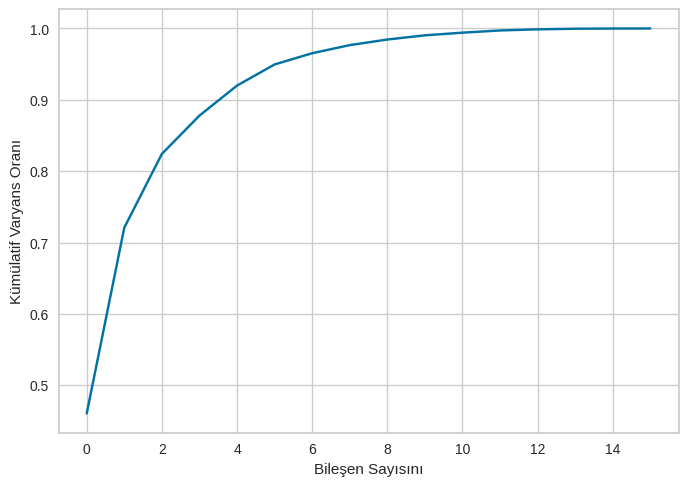

In [34]:
pca = PCA().fit(df)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Bileşen Sayısını")
plt.ylabel("Kümülatif Varyans Oranı")
plt.show()


In [35]:
pca = PCA(n_components=3)
pca_fit = pca.fit_transform(df)

pca.explained_variance_ratio_
np.cumsum(pca.explained_variance_ratio_)


array([0.46037855, 0.26039849, 0.1033886 ])

array([0.46037855, 0.72077704, 0.82416565])

In [36]:
df = pd.read_csv("/content/hitters.csv")
df.shape

len(pca_fit)

num_cols = [col for col in df.columns if df[col].dtypes != "O" and "Salary" not in col]
len(num_cols)

others = [col for col in df.columns if col not in num_cols]

pd.DataFrame(pca_fit, columns=["PC1","PC2","PC3"]).head()

df[others].head()

final_df = pd.concat([pd.DataFrame(pca_fit, columns=["PC1","PC2","PC3"]),
                      df[others]], axis=1)
final_df.head()


from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

for col in ["NewLeague", "Division", "League"]:
    label_encoder(final_df, col)

final_df.dropna(inplace=True)

y = final_df["Salary"]
X = final_df.drop(["Salary"], axis=1)

lm = LinearRegression()
rmse = np.mean(np.sqrt(-cross_val_score(lm, X, y, cv=5, scoring="neg_mean_squared_error")))
y.mean()


cart = DecisionTreeRegressor()
rmse = np.mean(np.sqrt(-cross_val_score(cart, X, y, cv=5, scoring="neg_mean_squared_error")))

cart_params = {'max_depth': range(1, 11),
               "min_samples_split": range(2, 20)}

# GridSearchCV
cart_best_grid = GridSearchCV(cart,
                              cart_params,
                              cv=5,
                              n_jobs=-1,
                              verbose=True).fit(X, y)

cart_final = DecisionTreeRegressor(**cart_best_grid.best_params_, random_state=17).fit(X, y)

rmse = np.mean(np.sqrt(-cross_val_score(cart_final, X, y, cv=5, scoring="neg_mean_squared_error")))


(322, 20)

322

16

,PC1,PC2,PC3
0,-3.240106,0.253173,0.776066
1,0.245488,-1.302951,0.118040
2,0.603883,2.617002,-0.698183
3,3.591276,-0.547821,-1.049022
4,-2.264528,0.698898,-1.290536


,League,Division,Salary,NewLeague
0,A,E,NaN,A
1,N,W,475.0,N
2,A,W,480.0,A
3,N,E,500.0,N
4,N,E,91.5,N


...

,PC1,PC2,PC3,League,Division,Salary,NewLeague
0,-3.240106,0.253173,0.776066,A,E,NaN,0
1,0.245488,-1.302951,0.118040,N,W,475.0,1
2,0.603883,2.617002,-0.698183,A,W,480.0,0
3,3.591276,-0.547821,-1.049022,N,E,500.0,1
4,-2.264528,0.698898,-1.290536,N,E,91.5,1
...,...,...,...,...,...,...,...
317,-0.089503,0.521050,-0.770721,N,E,700.0,1
318,3.339811,0.732713,3.114194,A,E,875.0,0
319,-0.951442,0.910086,0.286517,A,W,385.0,0
320,2.091473,2.265826,-0.192745,A,E,960.0,0


,PC1,PC2,PC3,League,Division,Salary,NewLeague
0,-3.240106,0.253173,0.776066,A,0,NaN,0
1,0.245488,-1.302951,0.118040,N,1,475.0,1
2,0.603883,2.617002,-0.698183,A,1,480.0,0
3,3.591276,-0.547821,-1.049022,N,0,500.0,1
4,-2.264528,0.698898,-1.290536,N,0,91.5,1
...,...,...,...,...,...,...,...
317,-0.089503,0.521050,-0.770721,N,0,700.0,1
318,3.339811,0.732713,3.114194,A,0,875.0,0
319,-0.951442,0.910086,0.286517,A,1,385.0,0
320,2.091473,2.265826,-0.192745,A,0,960.0,0


,PC1,PC2,PC3,League,Division,Salary,NewLeague
0,-3.240106,0.253173,0.776066,0,0,NaN,0
1,0.245488,-1.302951,0.118040,1,1,475.0,1
2,0.603883,2.617002,-0.698183,0,1,480.0,0
3,3.591276,-0.547821,-1.049022,1,0,500.0,1
4,-2.264528,0.698898,-1.290536,1,0,91.5,1
...,...,...,...,...,...,...,...
317,-0.089503,0.521050,-0.770721,1,0,700.0,1
318,3.339811,0.732713,3.114194,0,0,875.0,0
319,-0.951442,0.910086,0.286517,0,1,385.0,0
320,2.091473,2.265826,-0.192745,0,0,960.0,0


np.float64(535.9258821292775)

Fitting 5 folds for each of 180 candidates, totalling 900 fits


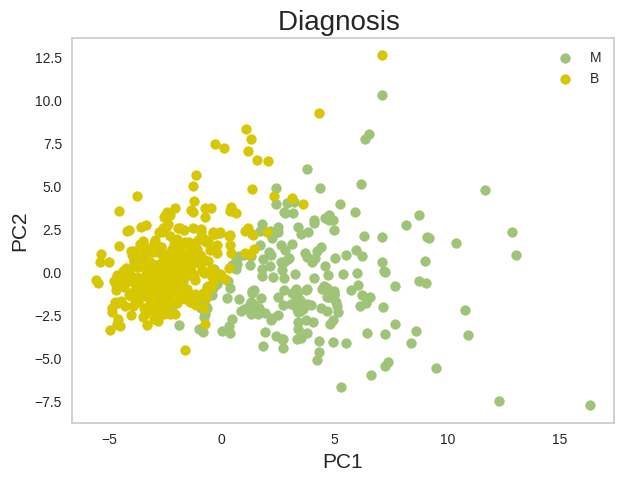

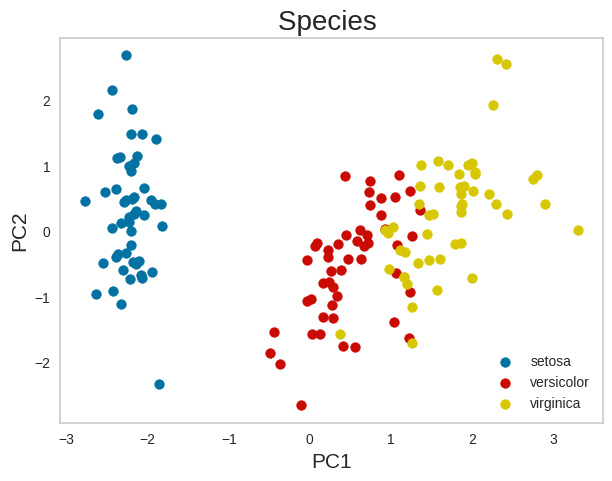

In [37]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)

df = pd.read_csv("/content/breast_cancer.csv")

y = df["diagnosis"]
X = df.drop(["diagnosis", "id"], axis=1)


def create_pca_df(X, y):
    X = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2)
    pca_fit = pca.fit_transform(X)
    pca_df = pd.DataFrame(data=pca_fit, columns=['PC1', 'PC2'])
    final_df = pd.concat([pca_df, pd.DataFrame(y)], axis=1)
    return final_df

pca_df = create_pca_df(X, y)

def plot_pca(dataframe, target):
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(1, 1, 1)
    ax.set_xlabel('PC1', fontsize=15)
    ax.set_ylabel('PC2', fontsize=15)
    ax.set_title(f'{target.capitalize()} ', fontsize=20)

    targets = list(dataframe[target].unique())
    colors = random.sample(['r', 'b', "g", "y"], len(targets))

    for t, color in zip(targets, colors):
        indices = dataframe[target] == t
        ax.scatter(dataframe.loc[indices, 'PC1'], dataframe.loc[indices, 'PC2'], c=color, s=50)
    ax.legend(targets)
    ax.grid()
    plt.show()

plot_pca(pca_df, "diagnosis")


################################
# Iris
################################

import seaborn as sns
df = sns.load_dataset("iris")

y = df["species"]
X = df.drop(["species"], axis=1)

pca_df = create_pca_df(X, y)

plot_pca(pca_df, "species")



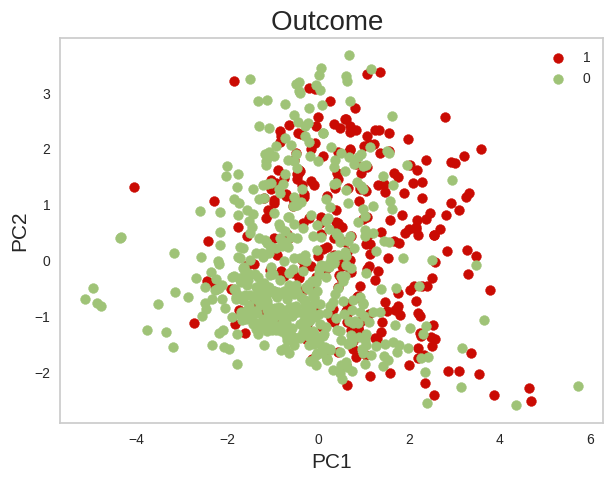

In [38]:
df = pd.read_csv("/content/diabetes.csv")

y = df["Outcome"]
X = df.drop(["Outcome"], axis=1)

pca_df = create_pca_df(X, y)

plot_pca(pca_df, "Outcome")